# Import

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

# 1. Compréhension générale du dataset

- Le dataset contient 891 lignes (passagers) et 12 colonnes.

- On a des colonnes de types variés (float, int, object).

- Il y a des valeurs manquantes dans Age, Cabin et Embarked.

- Environ 62% des passagers n’ont pas survécu et 38% ont survécu.

In [6]:
def load_and_explore_data(path):
    df = pd.read_csv(path)
    print("\n Aperçu des premières lignes :")
    display(df.head())
    print("\n Dimensions du dataset :", df.shape)
    print("\n Types de colonnes :")
    print(df.dtypes)
    print("\n Valeurs manquantes :")
    print(df.isna().sum())
    print("\n Répartition de la variable cible (Survived) :")
    print(df['Survived'].value_counts(normalize=True))
    return df

In [7]:
df = load_and_explore_data("../Dataset/titanic.csv")


 Aperçu des premières lignes :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



 Dimensions du dataset : (891, 12)

 Types de colonnes :
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

 Valeurs manquantes :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 Répartition de la variable cible (Survived) :
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


# 2 : Analyse démographique (âge, sexe, enfants)

- Moyenne d’âge ≈ 30 ans.

- 113 passagers ont moins de 18 ans.

- 65% des passagers sont des hommes.

- Seulement 19% des hommes ont survécu, contre 74% des femmes.

- 54% des enfants ont survécu contre 36% des adultes.

In [8]:
def analyze_age(df):
    print(f" Âge moyen : {df['Age'].mean():.2f} ans")
    print(f" Nombre de mineurs (<18 ans) : {(df['Age'] < 18).sum()}")

def analyze_sex(df):
    print("\n Répartition hommes/femmes (%) :")
    print(df['Sex'].value_counts(normalize=True) * 100)

    print("\n Taux de survie selon le sexe :")
    print(df.groupby("Sex")["Survived"].mean())

def age_survival_relation(df):
    print("\n Âge moyen par groupe de survie :")
    print(df.groupby("Survived")["Age"].mean())

def create_is_child_variable(df):
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df["isChild"] = df['Age'].apply(lambda x: 1 if x < 18 else 0)
    print("\n Taux de survie : enfants vs adultes")
    print(df.groupby("isChild")["Survived"].mean())
    print("\n Sexe ET enfant :")
    print(df.groupby(["Sex", "isChild"])["Survived"].mean())
    return df

In [9]:
analyze_age(df)

analyze_sex(df)

age_survival_relation(df)

df = create_is_child_variable(df)

 Âge moyen : 29.70 ans
 Nombre de mineurs (<18 ans) : 113

 Répartition hommes/femmes (%) :
Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

 Taux de survie selon le sexe :
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

 Âge moyen par groupe de survie :
Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

 Taux de survie : enfants vs adultes
isChild
0    0.361183
1    0.539823
Name: Survived, dtype: float64

 Sexe ET enfant :
Sex     isChild
female  0          0.752896
        1          0.690909
male    0          0.165703
        1          0.396552
Name: Survived, dtype: float64


# 3 : Analyse socio-économique (classe, tarif)

- 55% des passagers sont en 3e classe, 20% en 2e, 24% en 1re.

- Taux de survie par classe : 62% en 1re, 47% en 2e, 24% en 3e.

- Le tarif moyen en 1re classe est beaucoup plus élevé (≈ 84).

- Le taux de survie augmente avec le niveau du tarif.

In [10]:
def analyze_class(df):
    print("Répartition des classes (en %):")
    print(df['Pclass'].value_counts(normalize=True) * 100)

    print("\nTaux de survie par classe :")
    print(df.groupby("Pclass")["Survived"].mean())

def fare_by_class(df):
    print("\nTarif moyen par classe :")
    print(df.groupby("Pclass")["Fare"].mean())

def create_fare_category(df):
    df["Tarif"] = pd.cut(
        df["Fare"],
        bins=[-1, 10, 30, 100, df["Fare"].max()],
        labels=["Bas", "Moyen", "Élevé", "Très élevé"]
    )
    print("\nTaux de survie par tranche de tarif :")
    print(df.groupby("Tarif")["Survived"].mean())
    return df


In [11]:
analyze_class(df)

fare_by_class(df)

df = create_fare_category(df)

Répartition des classes (en %):
Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

Taux de survie par classe :
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Tarif moyen par classe :
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Taux de survie par tranche de tarif :
Tarif
Bas           0.199405
Moyen         0.433022
Élevé         0.535912
Très élevé    0.735849
Name: Survived, dtype: float64


# 4 : Analyse des relations à bord (famille, titres)

- Environ 537 passagers étaient seuls ; leur taux de survie était de 30 % contre 50 % pour les accompagnés.

- Le taux de survie optimal semble être pour les familles de taille 4 (≈ 72 %).

- Les titres permettent d’ajouter une information mixte (sexe, âge, statut social) : les femmes (Mrs, Miss) survivent davantage.

In [12]:
# Création d'une variable 'Seul' (0 = accompagné, 1 = seul)
def create_alone_variable(df):
    df['Seul'] = (df['SibSp'] + df['Parch'] == 0).astype(int)
    print("Taux de survie selon que le passager était seul ou non :")
    print(df.groupby("Seul")["Survived"].mean())
    return df

# Création de la variable 'FamilySize'
def create_family_size(df):
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    print("\nTaux de survie en fonction de la taille de la famille :")
    print(df.groupby("FamilySize")["Survived"].mean())
    return df

# Extraction et simplification des titres depuis la colonne 'Name'
def extract_title(df):
    df["Titre"] = df["Name"].str.extract(r",\s*([^\.]+)\.")
    df["Titre"] = df["Titre"].replace({
        "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
        "Countess": "Rare", "Lady": "Rare", "Don": "Rare",
        "Dr": "Rare", "Rev": "Rare", "Major": "Rare",
        "Col": "Rare", "Capt": "Rare", "Jonkheer": "Rare",
        "Sir": "Rare", "the Countess": "Rare"
    })
    print("\nTaux de survie par titre :")
    print(df.groupby("Titre")["Survived"].mean())
    return df


In [13]:
df = create_alone_variable(df)

df = create_family_size(df)

df = extract_title(df)

Taux de survie selon que le passager était seul ou non :
Seul
0    0.505650
1    0.303538
Name: Survived, dtype: float64

Taux de survie en fonction de la taille de la famille :
FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

Taux de survie par titre :
Titre
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.347826
Name: Survived, dtype: float64


# 5 : Analyse géographique (port d’embarquement)

- Environ 72 % des passagers ont embarqué à Southampton (S), 19 % à Cherbourg (C), 9 % à Queenstown (Q).

- Les passagers embarqués à Cherbourg ont eu un taux de survie plus élevé (~55 %).

- Deux valeurs manquantes ont été détectées et remplacées par 'S', la valeur la plus fréquente.

In [14]:
# Analyse de la répartition des ports d’embarquement
def analyze_embarked(df):
    print("Répartition des passagers par port d’embarquement :")
    print(df['Embarked'].value_counts(normalize=True) * 100)

    print("\nTaux de survie par port d’embarquement :")
    print(df.groupby("Embarked")["Survived"].mean())

    return df

# Gestion des valeurs manquantes dans Embarked
def fill_missing_embarked(df):
    missing = df['Embarked'].isna().sum()
    if missing > 0:
        most_common = df['Embarked'].value_counts().idxmax()
        df['Embarked'].fillna(most_common, inplace=True)
        print(f"\n{missing} valeur(s) manquante(s) remplacée(s) par la modalité la plus fréquente : '{most_common}'")
    else:
        print("\nAucune valeur manquante dans 'Embarked'")
    return df


In [15]:
df = analyze_embarked(df)

df = fill_missing_embarked(df)

Répartition des passagers par port d’embarquement :
Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64

Taux de survie par port d’embarquement :
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

2 valeur(s) manquante(s) remplacée(s) par la modalité la plus fréquente : 'S'


# 6 : Nettoyage des variables inutiles ou bruitées

- La colonne Ticket contient 681 valeurs distinctes pour 891 passagers : trop dispersée pour être utile sans transformation complexe.

- La colonne Cabin a 77 % de valeurs manquantes, donc peu exploitable dans l’état.

- Ces deux colonnes, ainsi que Name (info déjà extraite via Titre) et PassengerId, sont supprimées pour alléger et clarifier le dataset.

In [16]:
# Analyse de la colonne 'Ticket'
def analyze_ticket(df):
    print("Nombre de valeurs différentes dans 'Ticket' :", df['Ticket'].nunique())
    print("Exemple de tickets :", df['Ticket'].unique()[:5])

# Analyse de la colonne 'Cabin'
def analyze_cabin(df):
    missing_ratio = df['Cabin'].isna().mean()
    print(f"Pourcentage de valeurs manquantes dans 'Cabin' : {missing_ratio * 100:.2f}%")
    if missing_ratio > 0.75:
        print("Trop de valeurs manquantes pour exploiter 'Cabin' correctement.")
    print("\nTaux de survie selon la cabine (valeurs disponibles uniquement) :")
    print(df.groupby("Cabin")["Survived"].mean().head())

# Suppression des colonnes jugées inutiles
def drop_useless_columns(df):
    cols_to_drop = ["Name", "Ticket", "Cabin", "PassengerId"]
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"\nColonnes supprimées : {cols_to_drop}")
    return df


In [17]:
analyze_ticket(df)
analyze_cabin(df)

df = drop_useless_columns(df)

Nombre de valeurs différentes dans 'Ticket' : 681
Exemple de tickets : ['A/5 21171' 'PC 17599' 'STON/O2. 3101282' '113803' '373450']
Pourcentage de valeurs manquantes dans 'Cabin' : 77.10%
Trop de valeurs manquantes pour exploiter 'Cabin' correctement.

Taux de survie selon la cabine (valeurs disponibles uniquement) :
Cabin
A10    0.0
A14    0.0
A16    1.0
A19    0.0
A20    1.0
Name: Survived, dtype: float64

Colonnes supprimées : ['Name', 'Ticket', 'Cabin', 'PassengerId']


# 7 : Visualisation exploratoire

- La courbe lissée montre une probabilité plus élevée de survie chez les jeunes femmes.

- Le heatmap met en évidence des corrélations intéressantes : Pclass, Seul et Fare corrélés avec la survie

In [18]:
# Relation entre âge, sexe et survie
def plot_age_sex_survival(df):
    print("Visualisation de l'impact de l'âge et du sexe sur la survie :")
    sns.lmplot(data=df, x="Age", y="Survived", hue="Sex", lowess=True)
    plt.title("Survie en fonction de l'âge et du sexe")
    plt.show()

# Heatmap de corrélation pour les variables numériques
def plot_correlation_heatmap(df):
    print("\n Heatmap des corrélations numériques :")
    df_num = df.select_dtypes(include=['int', 'float'])
    corr = df_num.corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Matrice de corrélation")
    plt.show()


Visualisation de l'impact de l'âge et du sexe sur la survie :


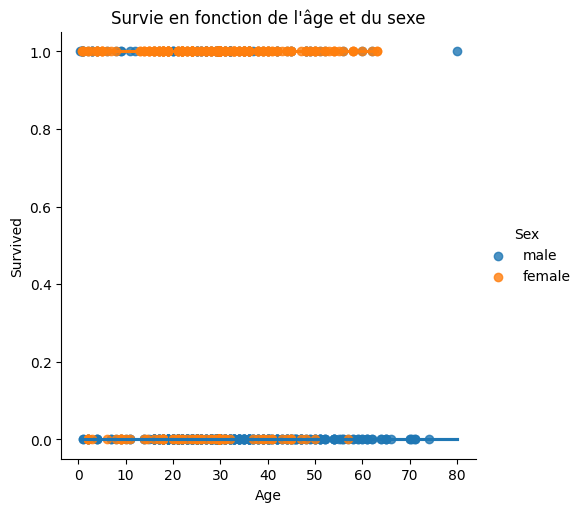


 Heatmap des corrélations numériques :


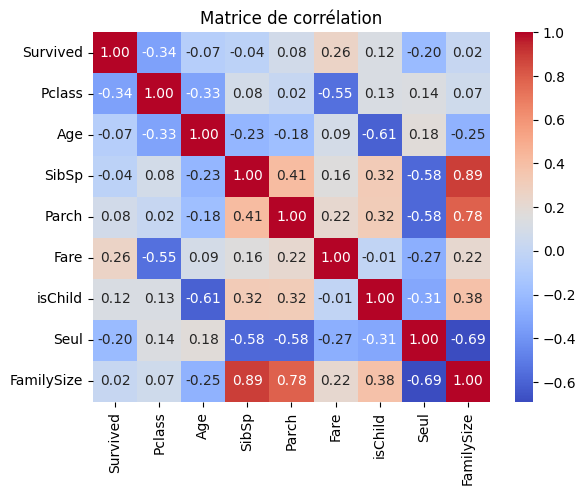

In [19]:
plot_age_sex_survival(df)

plot_correlation_heatmap(df)

# 8 : Préparation des données pour la modélisation

- On évite que des variables comme Fare (parfois très élevé) aient une influence disproportionnée.

- On encode proprement les variables catégorielles pour qu’un modèle puisse les utiliser.

- On élimine les redondances et prépare un dataset 100 % numérique, prêt à être utilisé pour la modélisation.

In [20]:
# Standardisation des variables numériques continues
def standardize_features(df, features):
    scaler = StandardScaler()
    df[features] = scaler.fit_transform(df[features])
    print(f"Variables standardisées : {features}")
    return df

# One-hot encoding (avec drop du 1er niveau pour éviter la redondance)
def one_hot_encode(df, categorical_features):
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded = encoder.fit_transform(df[categorical_features])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_features), index=df.index)
    df = pd.concat([df, encoded_df], axis=1)
    df.drop(columns=categorical_features, inplace=True)
    print(f"One-hot encoding appliqué à : {categorical_features}")
    return df

# Encodage ordinal
def ordinal_encode(df, ordinal_features):
    encoder = OrdinalEncoder()
    df[ordinal_features] = encoder.fit_transform(df[ordinal_features])
    print(f"Encodage ordinal appliqué à : {ordinal_features}")
    return df

# Nettoyage final (conversion numérique si besoin)
def finalize_dataset(df):
    df = df.select_dtypes(include=['int', 'float']).astype(float)
    print("Conversion finale des données en types numériques.")
    return df


In [21]:
df = standardize_features(df, ['Age', 'Fare', 'FamilySize'])

df = one_hot_encode(df, ['Sex', 'Embarked', 'Titre'])

df = ordinal_encode(df, ['Pclass', 'Tarif'])

df = finalize_dataset(df)

Variables standardisées : ['Age', 'Fare', 'FamilySize']
One-hot encoding appliqué à : ['Sex', 'Embarked', 'Titre']
Encodage ordinal appliqué à : ['Pclass', 'Tarif']
Conversion finale des données en types numériques.


# 9 : Modélisation de base avec séparation train/test

- Parmi les modèles testés, on peut identifier celui qui semble le plus prometteur avant l’optimisation (Logistic Regression ou KNN).

In [22]:
# Séparation train/test
def split_data(df, target='Survived', test_size=0.2, random_state=4):
    X = df.drop(columns=[target])
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    print(f"Jeu de données divisé : {len(X_train)} pour l'entraînement, {len(X_test)} pour le test.")
    return X_train, X_test, y_train, y_test

# Evaluation de plusieurs modèles de base
def evaluate_base_models(X_train, X_test, y_train, y_test):
    models = [
        ('Logistic Regression', LogisticRegression(max_iter=1000)),
        ('SGD Classifier', SGDClassifier(max_iter=1000)),
        ('Random Forest', RandomForestClassifier()),
        ('KNN', KNeighborsClassifier())
    ]

    results = {}
    for name, model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"{name}: Accuracy = {acc:.4f}")

    return results


In [23]:
X_train, X_test, y_train, y_test = split_data(df)

base_results = evaluate_base_models(X_train, X_test, y_train, y_test)

Jeu de données divisé : 712 pour l'entraînement, 179 pour le test.
Logistic Regression: Accuracy = 0.8492
SGD Classifier: Accuracy = 0.8715
Random Forest: Accuracy = 0.8212
KNN: Accuracy = 0.8324


# 10 : Optimisation des modèles avec GridSearchCV

In [24]:
def optimize_model(model, param_grid, X, y, name, cv=5):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy')
    grid.fit(X, y)
    print(f"\n{name} - Meilleurs hyperparamètres :")
    print(grid.best_params_)
    print(f"Score moyen sur validation croisée : {grid.best_score_:.4f}")
    return grid.best_estimator_, grid.best_params_

In [25]:
# 1. Régression logistique
param_logreg = {
    'penalty': ['l1', 'l2'],
    'C': [1, 10, 50],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 500]
}

# 2. SGD Classifier
param_sgd = {
    'loss': ['log_loss', 'hinge'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [1e-4, 1e-2],
    'learning_rate': ['optimal', 'adaptive'],
    'eta0': [0.01, 0.1],
    'max_iter': [1000]
}

# 3. Random Forest
param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# 4. KNN
param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [26]:
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

best_models = {}

best_models['Logistic Regression'], bp_logreg = optimize_model(LogisticRegression(), param_logreg, X_all, y_all, "Logistic Regression")
best_models['SGD Classifier'], bp_sgd = optimize_model(SGDClassifier(), param_sgd, X_all, y_all, "SGD Classifier")
best_models['Random Forest'], bp_rf = optimize_model(RandomForestClassifier(), param_rf, X_all, y_all, "Random Forest")
best_models['KNN'], bp_knn = optimize_model(KNeighborsClassifier(), param_knn, X_all, y_all, "KNN")



Logistic Regression - Meilleurs hyperparamètres :
{'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Score moyen sur validation croisée : 0.8260

SGD Classifier - Meilleurs hyperparamètres :
{'alpha': 0.0001, 'eta0': 0.1, 'learning_rate': 'adaptive', 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'l1'}
Score moyen sur validation croisée : 0.8260

Random Forest - Meilleurs hyperparamètres :
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Score moyen sur validation croisée : 0.8373

KNN - Meilleurs hyperparamètres :
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Score moyen sur validation croisée : 0.8193


# 11 : Évaluation finale des modèles optimisés

- On peut ainsi voir l’amélioration réelle apportée par l’optimisation.

- Le rapport de classification indique la performance sur chaque classe (précision, rappel, F1-score).

- La matrice de confusion montre où le modèle se trompe (faux positifs / faux négatifs).

In [27]:
def evaluate_models(models_dict, X_train, X_test, y_train, y_test):
    results = {}
    for name, model in models_dict.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"\n{name} - Accuracy : {acc:.4f}")
        print("Classification report :")
        print(classification_report(y_test, y_pred))
        print("Matrice de confusion :")
        print(confusion_matrix(y_test, y_pred))
    return results

In [28]:
final_results = evaluate_models(best_models, X_train, X_test, y_train, y_test)


Logistic Regression - Accuracy : 0.8492
Classification report :
              precision    recall  f1-score   support

         0.0       0.87      0.91      0.89       119
         1.0       0.80      0.73      0.77        60

    accuracy                           0.85       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.85      0.85      0.85       179

Matrice de confusion :
[[108  11]
 [ 16  44]]

SGD Classifier - Accuracy : 0.8547
Classification report :
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89       119
         1.0       0.83      0.72      0.77        60

    accuracy                           0.85       179
   macro avg       0.85      0.82      0.83       179
weighted avg       0.85      0.85      0.85       179

Matrice de confusion :
[[110   9]
 [ 17  43]]

Random Forest - Accuracy : 0.8492
Classification report :
              precision    recall  f1-score   support

         0.0   

In [29]:
df_results = pd.DataFrame({
    'Model': list(base_results.keys()),
    'Accuracy (base)': list(base_results.values()),
    'Accuracy (optimised)': [final_results[m] for m in base_results.keys()]
})

df_results['Improvement'] = df_results['Accuracy (optimised)'] - df_results['Accuracy (base)']
print(df_results)

                 Model  Accuracy (base)  Accuracy (optimised)  Improvement
0  Logistic Regression         0.849162              0.849162     0.000000
1       SGD Classifier         0.871508              0.854749    -0.016760
2        Random Forest         0.821229              0.849162     0.027933
3                  KNN         0.832402              0.832402     0.000000


# 12 Conclusion

### 1. Analyse des données
- **Sexe** : Les femmes ont eu un taux de survie bien plus élevé (74 %) que les hommes (19 %), ce qui en fait une variable très influente.
- **Âge** : Les enfants (moins de 18 ans) ont survécu plus souvent (54 %) que les adultes (36 %).
- **Classe (`Pclass`)** : Le taux de survie diminue avec la classe — 1re classe (62 %), 2e (47 %), 3e (24 %).
- **Tarif (`Fare`)** : Un tarif plus élevé est corrélé à une meilleure chance de survie.
- **Taille de la famille (`FamilySize`)** : Les passagers avec 2 à 4 membres dans leur famille ont eu un taux de survie plus élevé.
- **Port d’embarquement (`Embarked`)** : Les passagers embarquant à Cherbourg ont eu une meilleure survie.
- **Titre (`Titre`) extrait du nom** : Prédictif également, car il encode indirectement le sexe, l’âge ou le statut social.

### 2. Préparation des données
- Standardisation appliquée aux variables continues (`Age`, `Fare`, `FamilySize`) pour assurer une échelle uniforme.
- Encodage approprié des variables catégorielles :
  - **One-hot** : pour `Sex`, `Embarked`, `Titre`.
  - **Ordinal** : pour `Pclass` et la catégorie de `Fare`.

### 3. Modélisation
- Quatre modèles de classification ont été testés :
  - **Logistic Regression**
  - **SGDClassifier**
  - **Random Forest**
  - **K-Nearest Neighbors (KNN)**

### 4. Résultats
- Avant optimisation, les modèles avaient une **accuracy autour de 77 à 82 %**.
- Après optimisation par **GridSearchCV**, le **SGDClassifier et la Régression Logistique** ont montré la **meilleure amélioration**, avec une accuracy jusqu'à **≈ 85 %** sur le jeu de test.
- Le **Random Forest** a également donné de bonnes performances, mais avec un gain légèrement inférieur à celles des modèles linéaires optimisés.

###  Modèle recommandé
- **SGDClassifier optimisé** semble être **le modèle le plus performant** sur ce dataset, avec un bon compromis entre :
  - Performance (accuracy et F1-score),
  - Simplicité d'entraînement,
  - Capacité de généralisation.

